In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
from netCDF4 import Dataset 
import os
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import pandas as pd
import seaborn as sns
import numpy as np
import plotly.express as px

import pathlib
import cartopy.feature as cfeature
from matplotlib import pyplot as plt
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize

import plotly.express as px
import plotly.graph_objects as go

import torch
from torchdata.datapipes.iter import FileLister, FileOpener




In [23]:
import torch
from tfrecord.torch.dataset import TFRecordDataset

tfrecord_path = '../../../salman/year24_hr/ml_ecrad_ape_R2B05_myrunscript_1year_183min_HR_atm_3d_DOM01_ml_0001_lonlat_sample17325.05.tfrecord'

#tfrecord_path  = '../../../salman/year24_hr'

if not os.path.exists(tfrecord_path):
    print("File does not exist at:", tfrecord_path)
else:
    print("File found.")


dataset = TFRecordDataset(tfrecord_path, index_path = None) #, transform=lambda x: len(x))
loader = torch.utils.data.DataLoader(dataset, batch_size=3)

data = next(iter(loader))
print(data)


# index_path = None
# description = {"image": "byte", "label": "float"}
# dataset = TFRecordDataset(tfrecord_path, index_path, description)
# loader = torch.utils.data.DataLoader(dataset, batch_size=32)

# data = next(iter(loader))
# print(data)


"""
Use these tensors as input to a machine learning model. For neural networks in PyTorch, 
you typically need to convert these tensors to the appropriate shape and type.
"""

File found.
{'ddt_temp_radlw_52': tensor([[-3.0079e-06, -3.0143e-06, -3.0155e-06,  ..., -2.7107e-06,
         -2.7036e-06, -2.7534e-06]]), 'ddt_temp_radsw_57': tensor([[0., 0., 0.,  ..., 0., 0., 0.]]), 'ddt_temp_radlw_19': tensor([[-3.8256e-05, -2.0584e-05, -5.2222e-05,  ..., -1.8432e-05,
         -1.7078e-05, -2.5332e-05]]), 'pres_ifc_62': tensor([[63.9087, 63.8648, 63.8786,  ..., 61.3614, 61.3508, 61.2038]]), 'ddt_temp_radsw_16': tensor([[0., 0., 0.,  ..., 0., 0., 0.]]), 'ddt_temp_radsw_45': tensor([[0., 0., 0.,  ..., 0., 0., 0.]]), 'pres_ifc_51': tensor([[1324.6211, 1325.5153, 1325.1355,  ..., 1283.3860, 1283.5858,
         1282.9908]]), 'ddt_temp_radsw_61': tensor([[0., 0., 0.,  ..., 0., 0., 0.]]), 'ddt_temp_radlw_63': tensor([[-5.7932e-06, -5.9065e-06, -5.8236e-06,  ..., -4.1267e-06,
         -4.1846e-06, -4.3952e-06]]), 'pres_ifc_18': tensor([[66979.8047, 66937.8750, 66994.1406,  ..., 68287.3828, 68283.5234,
         68311.0547]]), 'pres_ifc_29': tensor([[32894.9766, 32924.4922, 

'\nUse these tensors as input to a machine learning model. For neural networks in PyTorch, \nyou typically need to convert these tensors to the appropriate shape and type.\n'

Number of samples in the batch: 1
Feature: ddt_temp_radlw_52
  Data type: torch.float32
  Shape of data: torch.Size([1, 81920])
Feature: ddt_temp_radsw_57
  Data type: torch.float32
  Shape of data: torch.Size([1, 81920])
Feature: ddt_temp_radlw_19
  Data type: torch.float32
  Shape of data: torch.Size([1, 81920])
Feature: pres_ifc_62
  Data type: torch.float32
  Shape of data: torch.Size([1, 81920])
Feature: ddt_temp_radsw_16
  Data type: torch.float32
  Shape of data: torch.Size([1, 81920])
Feature: ddt_temp_radsw_45
  Data type: torch.float32
  Shape of data: torch.Size([1, 81920])
Feature: pres_ifc_51
  Data type: torch.float32
  Shape of data: torch.Size([1, 81920])
Feature: ddt_temp_radsw_61
  Data type: torch.float32
  Shape of data: torch.Size([1, 81920])
Feature: ddt_temp_radlw_63
  Data type: torch.float32
  Shape of data: torch.Size([1, 81920])
Feature: pres_ifc_18
  Data type: torch.float32
  Shape of data: torch.Size([1, 81920])
Feature: pres_ifc_29
  Data type: torch.floa

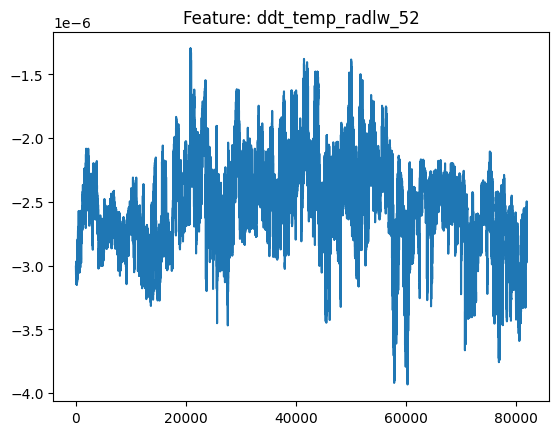

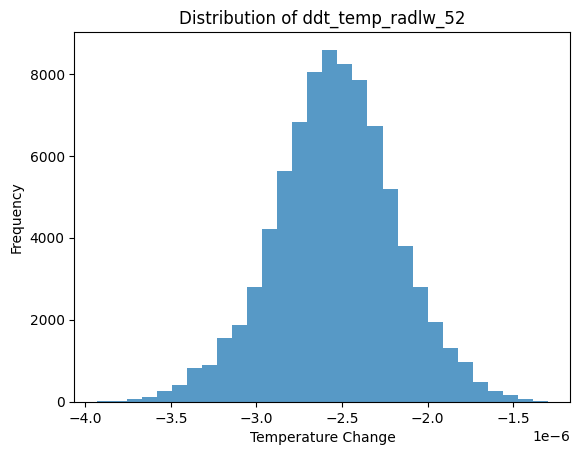

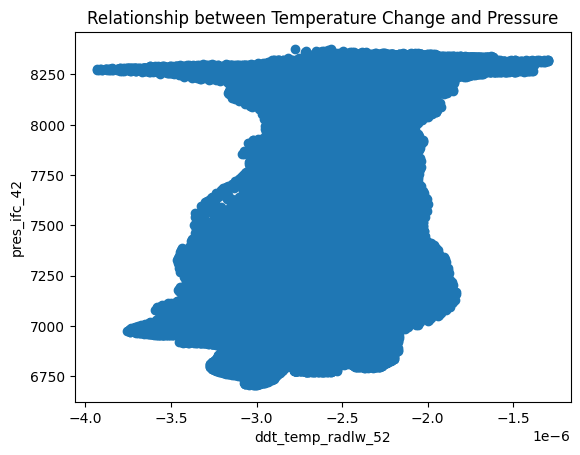

In [24]:
import matplotlib.pyplot as plt

# Assuming you've already loaded a batch as 'data'
print("Number of samples in the batch:", len(data[next(iter(data))]))

# To see the shapes and types of data in each feature of the batch:
for feature_name, feature_data in data.items():
    print(f"Feature: {feature_name}")
    print(f"  Data type: {feature_data.dtype}")
    print(f"  Shape of data: {feature_data.shape}")




# Assuming 'ddt_temp_radlw_52' is a feature that can be plotted
feature_data = data['ddt_temp_radlw_52'][0]  # Get the first batch item
plt.plot(feature_data.numpy())  # Convert tensor to numpy array if needed
plt.title('Feature: ddt_temp_radlw_52')
plt.show()

# Example: Plotting a histogram of the first batch of a temperature change due to longwave radiation
plt.hist(data['ddt_temp_radlw_52'][0].numpy(), bins=30, alpha=0.75)
plt.title('Distribution of ddt_temp_radlw_52')
plt.xlabel('Temperature Change')
plt.ylabel('Frequency')
plt.show()

# Example: Scatter plot comparing two features
plt.scatter(data['ddt_temp_radlw_52'][0].numpy(), data['pres_ifc_42'][0].numpy())
plt.xlabel('ddt_temp_radlw_52')
plt.ylabel('pres_ifc_42')
plt.title('Relationship between Temperature Change and Pressure')
plt.show()


ValueError: cannot reshape array of size 81920 into shape (69,1187)

In [6]:
os.chdir(os.getcwd())
file_path = '../../../salman/year24_hr'


# Create a DataPipe to list files matching the specific path
datapipe1 = FileLister(".", "*.tfrecord")

# Filter out to only include the specific file you're interested in
datapipe1 = datapipe1.filter(lambda x: x == file_path)

# Create a DataPipe to open the listed files in binary mode
datapipe2 = FileOpener(datapipe1, mode="b")

# Load data from the TFRecord file
tfrecord_loader_dp = datapipe2.load_from_tfrecord()

# Iterate through the dataset and print each example
for example in tfrecord_loader_dp:
    print(example)


ImportError: cannot import name 'descriptor' from 'google.protobuf' (unknown location)

In [8]:

# Print dimensions
print("\nDimensions:")
for dim, size in ds.dims.items():
    print(f"{dim}: size {size}")

# Print variables and selected attributes
print("\nVariables and Selected Descriptions:")
for var in ds.data_vars:
    print(f"\n{var}:")
    print(f"  Dimensions: {ds[var].dims}")
    print(f"  Size: {ds[var].size}")
    # print(f"  Data type: {ds[var].dtype}")
    # print(" Attributes:")
    if 'standard_name' in ds[var].attrs:
        print(f"    Name: {ds[var].attrs['long_name']}")
    if 'units' in ds[var].attrs:
        print(f"    Units: {ds[var].attrs['units']}")
    if 'param' in ds[var].attrs:
        print(f"    Param: {ds[var].attrs['param']}")

# Close the dataset
ds.close()



Dimensions:
time: size 239
ncells: size 81920
vertices: size 3
height: size 70
bnds: size 2
height_2: size 71

Variables and Selected Descriptions:

clon_bnds:
  Dimensions: ('ncells', 'vertices')
  Size: 245760

clat_bnds:
  Dimensions: ('ncells', 'vertices')
  Size: 245760

height_bnds:
  Dimensions: ('height', 'bnds')
  Size: 140

zsct_ecrad_in:
  Dimensions: ('time', 'ncells')
  Size: 19578880
    Name: time-dependent solar constant
    Units: -

cosmu0_ecrad_in:
  Dimensions: ('time', 'ncells')
  Size: 19578880
    Name: Cosine of solar zenith angle (before ecrad)
    Units: -

tsfctrad_ecrad_in:
  Dimensions: ('time', 'ncells')
  Size: 19578880
    Name: surface temperature at trad (before ecrad)
    Units: K

albvisdif_ecrad_in:
  Dimensions: ('time', 'ncells')
  Size: 19578880
    Name: UV visible albedo for diffuse radiation (before ecrad)

albvisdir_ecrad_in:
  Dimensions: ('time', 'ncells')
  Size: 19578880
    Name: UV visible albedo for direct radiation (before ecrad)

al

/tmp/ipykernel_15217/2845409907.py:3: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for dim, size in ds.dims.items():
